# Moment-Curvature

A moment-curvature analysis is performed using a uniaxial fiber section.

The geometry of the section is depicted below:

![](img/fiber-0004.png)

## Materials

In [1]:
#<hide>
import matplotlib.pyplot as plt
plt.style.use("thesis")
del plt

In [2]:

import xara
from xara.units.iks import inch, foot, ksi, kip 
import xara.units.iks as units

Fy = 60*ksi
Es = 29e3*ksi

# Define materials
materials = {
    "core": xara.UniaxialMaterial(
        type = "Concrete01",
        Fc  =  6*ksi,
        nu  =  0.2,
        ec0 =  0.004,
        Fcu =  5*ksi,
        ecu =  0.014
    ),
    "cover": xara.UniaxialMaterial(
        type = "Concrete01",
        Fc  =  -5*ksi,
        nu  =   0.2,
        ec0 =  -0.002,
        Fcu =  -0.0*ksi,
        ecu =  -0.006,
        # "lambda": 0.1,
        # "Ft": 0.65*ksi,
        # "Ets": 500. # Tension stiffening
    ),
    "rebar": xara.UniaxialMaterial(
        type = "Steel01",
        nu = 0.3,
        E  =   30e3*ksi,
        Fy =     60*ksi,
        b =   0.01
    )
}


## Geometry

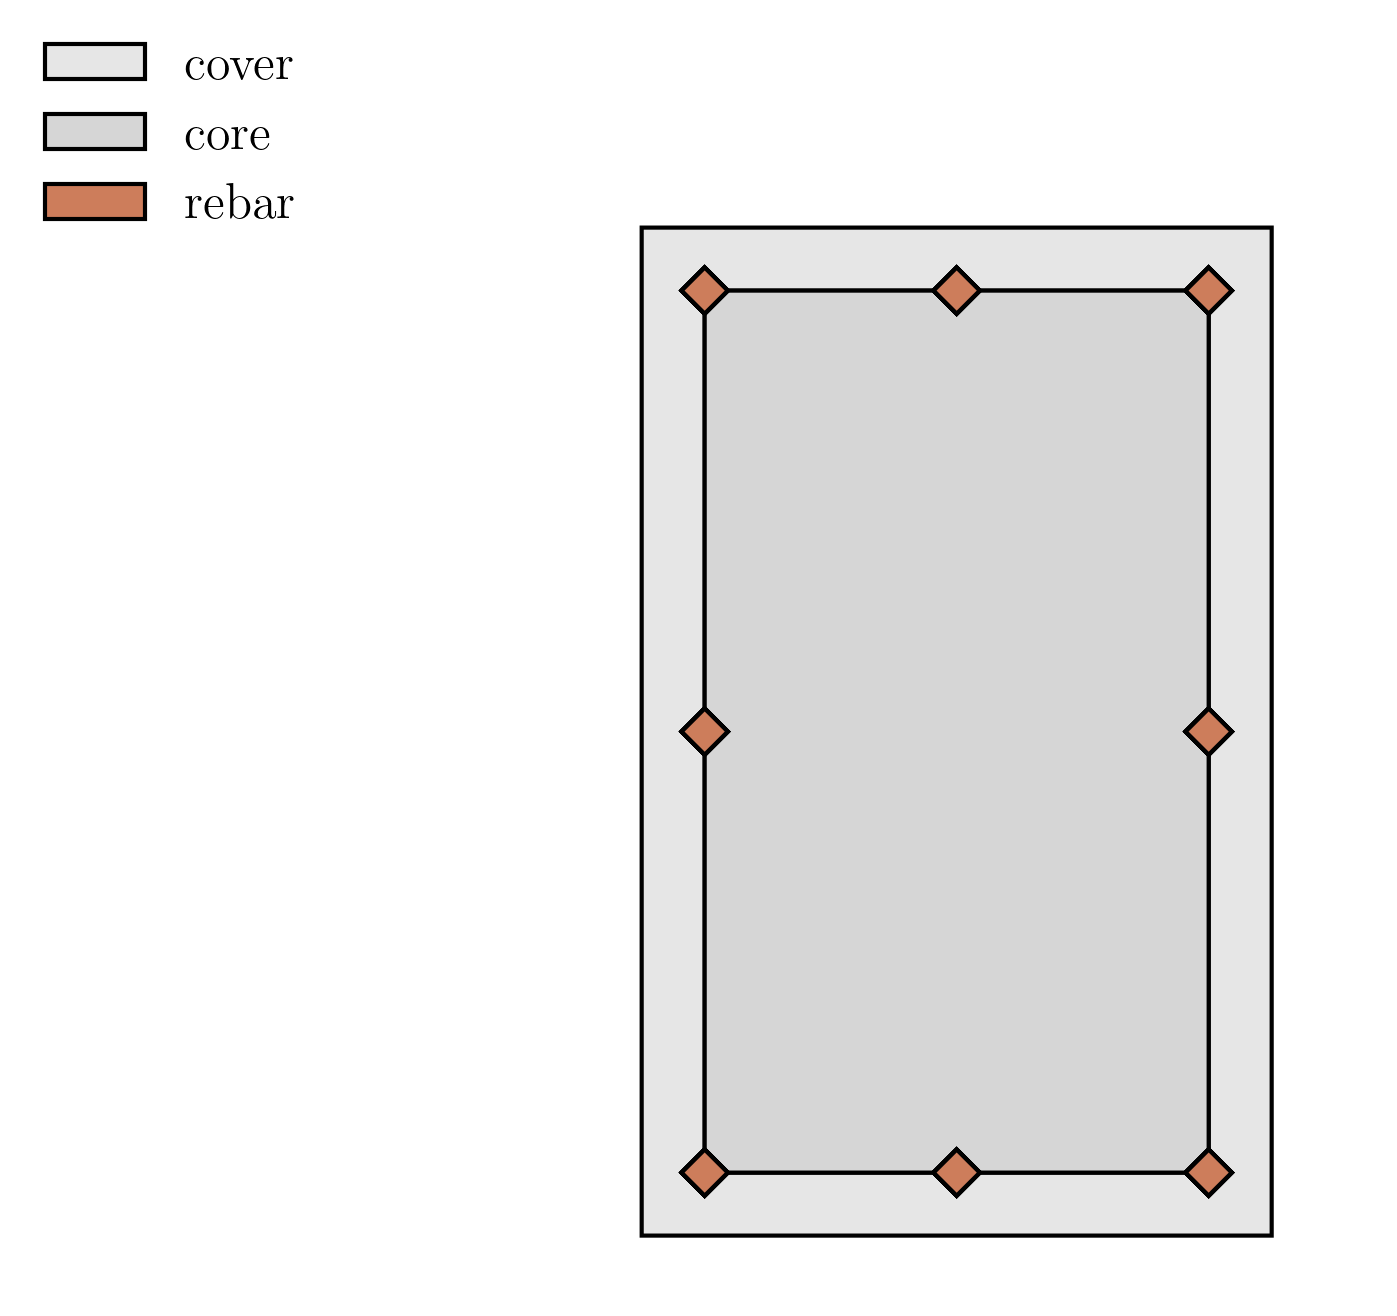

In [3]:
import veux
from xsection import CompositeSection
from xsection.library import Circle, Rectangle, HollowRectangle


# dimensions
b = width = 15.0*inch
h = depth = 24.0*inch
c         =  1.5*inch # cover
r = 0

As = 0.60*inch**2;        # area of no. 7 bars
r_bar = (7/16)*inch;      # radius of rebar

bar = Circle(radius=r_bar, 
             z=2, 
             material=materials["rebar"], 
             group="rebar", 
             divisions=4, 
             mesh_scale=1/2)
cover = HollowRectangle(b, h, t=c, z=0, 
                        group="cover", 
                        # mesh_scale=2,
                        material=materials["cover"]
)

core = Rectangle(b-2*c, h-2*c, z=1, 
                 mesh_scale=2,
                 group="core", material=materials["core"])

shape = CompositeSection([
            cover,
            core,
            *bar.linspace([-b/2+c+r, -h/2+c+r], [ b/2-c-r,-h/2+c+r], 3), # Top bars
            *bar.linspace([-b/2+c+r,        0], [ b/2-c-r,       0], 2), # Center bars
            *bar.linspace([-b/2+c+r,  h/2-c-r], [ b/2-c-r, h/2-c-r], 3)  # Bottom bars
        ])


veux.draw_shape(shape)

4
4
4
4
4
4
4
4
done


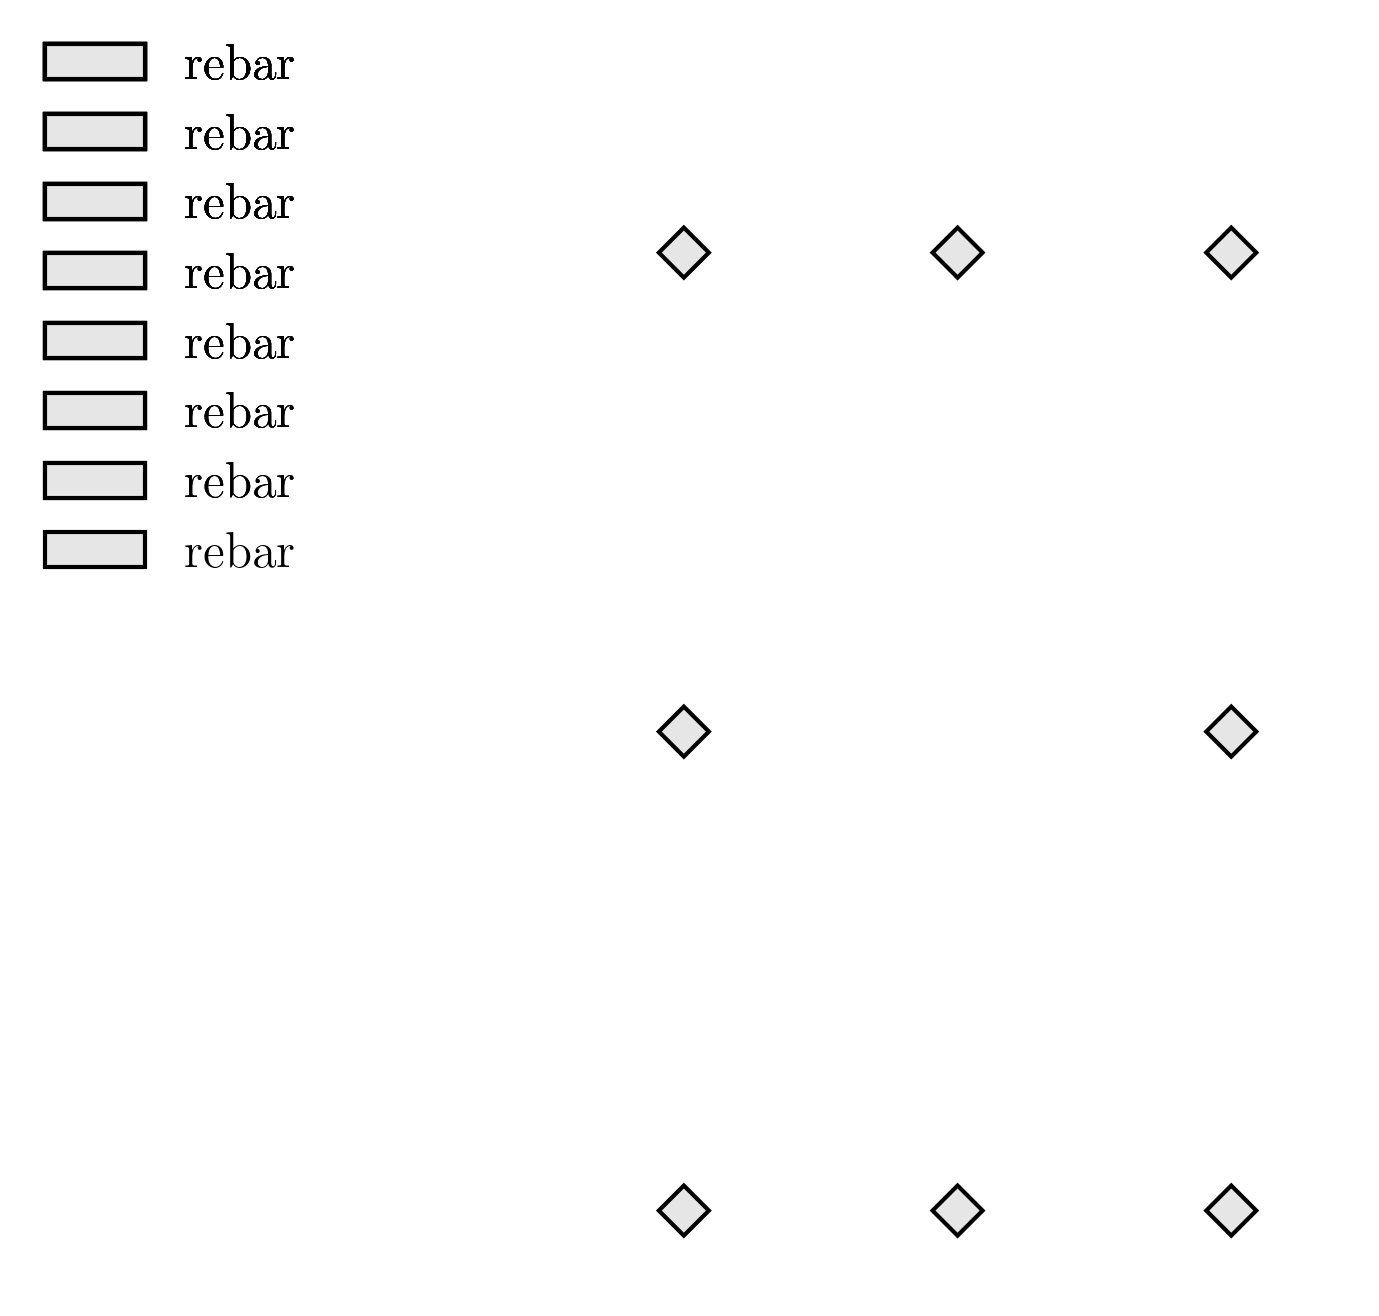

In [4]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
for s in shape._shapes:
    if "rebar" not in s._c_group:
        continue
    print(len(s.exterior()))

print("done")
for i, patch in enumerate(shape._patches):
    if "cover" in patch._c_group:
        continue
    if "core" in patch._c_group:
        continue

    assert patch.centroid in patch, f"{i}: {patch.centroid} not in \n{patch.exterior()} and {patch.interior()}"
    # print(patch.exterior())
    veux.draw_shape(patch, ax=ax)


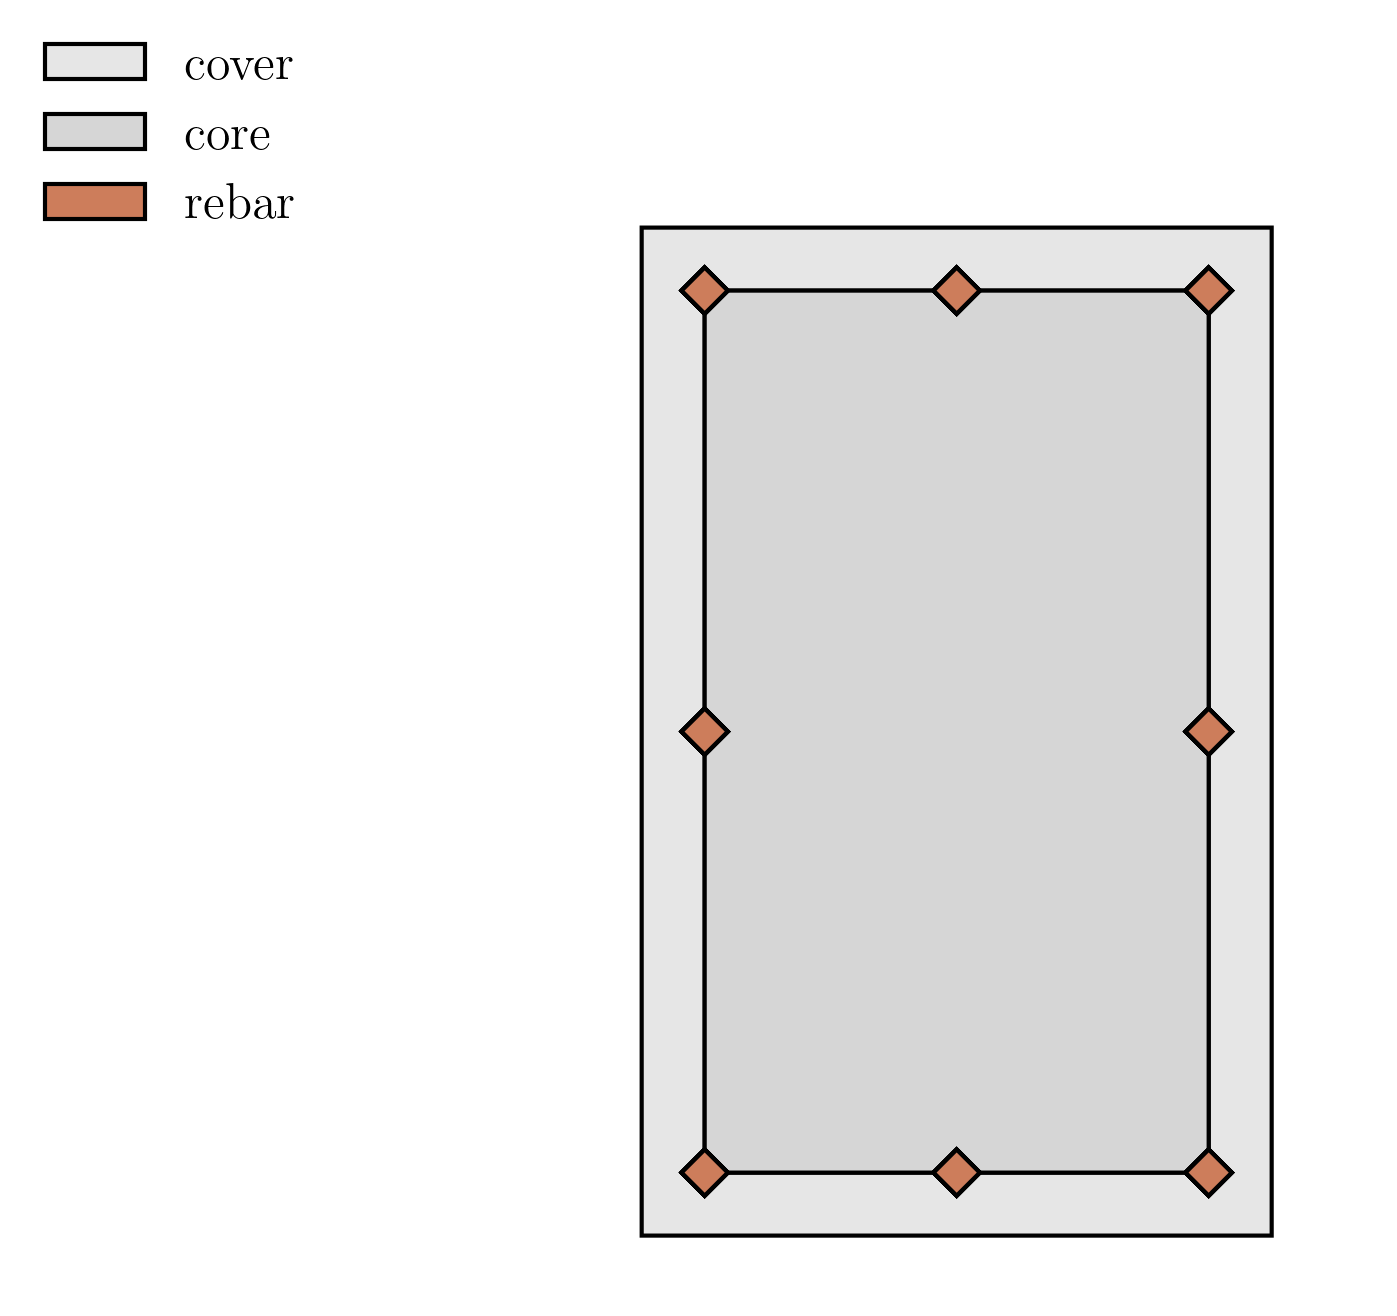

In [5]:
fibers = {
    "cover": {"d": 10, "t": 3, "b": 5},
    "core":  {"d": 10, "b": 5},
    "rebar": {"d": 1}
}

section = xara.FrameSection("UniaxialFiber", shape)#, fibers=fibers)

veux.draw_shape(section)

## Model

A {ref}`ZeroLengthSection <zeroLengthSection>` element is used.

In [6]:
def create_model(case, y=None, multiaxial=False):
    model = xara.Model(ndm=3, ndf=6)

    # Define two nodes at (0,0)
    model.node(1, (0.0, 0.0, 0))
    model.node(2, (0.0, 0.0, 0))

    # Fix all degrees of freedom except axial and bending
    model.fix(1, (1, 1, 1, 1, 1, 1))
    model.fix(2, (0, 1, 1, 1, 0, 1))

    stag = 1
    from xara.examples.Example2 import create_section, MultiaxialMaterials, UniaxialMaterials
    ms = MultiaxialMaterials(units) if multiaxial else UniaxialMaterials(units)
    create_section(model, ms, case, tag=stag, multiaxial=multiaxial)

    # # Define section
    # model.section(section)

    # Define element
    x = (1.0, 0.0, 0.0)
    if y is None:
        y = (0.0, 1.0, 0.0)
    model.element("ZeroLengthSection", 1, (1, 2), stag, y=y, x=x)

    return model


## Analysis

In [7]:
import numpy as np

def moment_curvature(case, axialLoad, maxK, numIncr, y=None, **kwds):
    """
    Arguments
       axialLoad -- axial load applied to section (negative is compression)
       maxK -- maximum curvature reached during analysis
       numIncr -- number of increments used to reach maxK (default 100)
    """
    model = create_model(case, y=y, **kwds)

    model.print(json=f"out/{case}.json")
    #
    # Apply axial loading
    #

    model.pattern("Plain", 1, "Constant", 
                  loads={2: [axialLoad, 0.0, 0.0, 0, 0, 0]}
    )

    analysis_A = xara.StaticAnalysis(model,
        integrator=xara.LoadFactorControl("Proportional", 0.0),
        algorithm="Newton",
        test=xara.Test("NormUnbalance", 1.0e-10, 10)
    )

    # Do one analysis for constant axial load
    analysis_A.analyze(1)

    #
    # Analyze in flexure
    #
    # Define reference moment
    model.pattern("Plain", 2, "Linear")
    model.load(2, (0, 0, 0, 0.0, 1.0, 0.0), pattern=2)

    # Compute curvature increment
    dK = maxK/numIncr


    # Use displacement control at node 2 for section analysis
    analysis = xara.StaticAnalysis(model,
        integrator=xara.LoadFactorControl("DisplacementControl", 2, 5, dK),
        algorithm="NewtonLineSearch",
        test=xara.Test("NormUnbalance", 1.0e-8, 20)
    )

    # Do the section analysis
    M,K = [0], [0]
    for i in range(numIncr):
        try:
            analysis.analyze(1)
        except:
            print(f"Analysis failed at step {i}")
            break
        K.append(model.nodeDisp(2, 5))
        M.append(model.getTime())

    return np.array([K,M])



In [8]:

P   =  -180.0   # Axial load
mu  =    20 #32.0   # Target ductility for analysis
numIncr = 100   # Number of analysis increments


# Estimate yield curvature
# (Assuming no axial load and only top and bottom steel)
d = depth - c   # distance from cover to rebar
epsy = Fy/Es # steel yield strain
# Ky = epsy/(0.7*d)
Ky = 0.000126984126984
Kz = epsy/(0.7*b)


H2
R1
P1
H3
H1


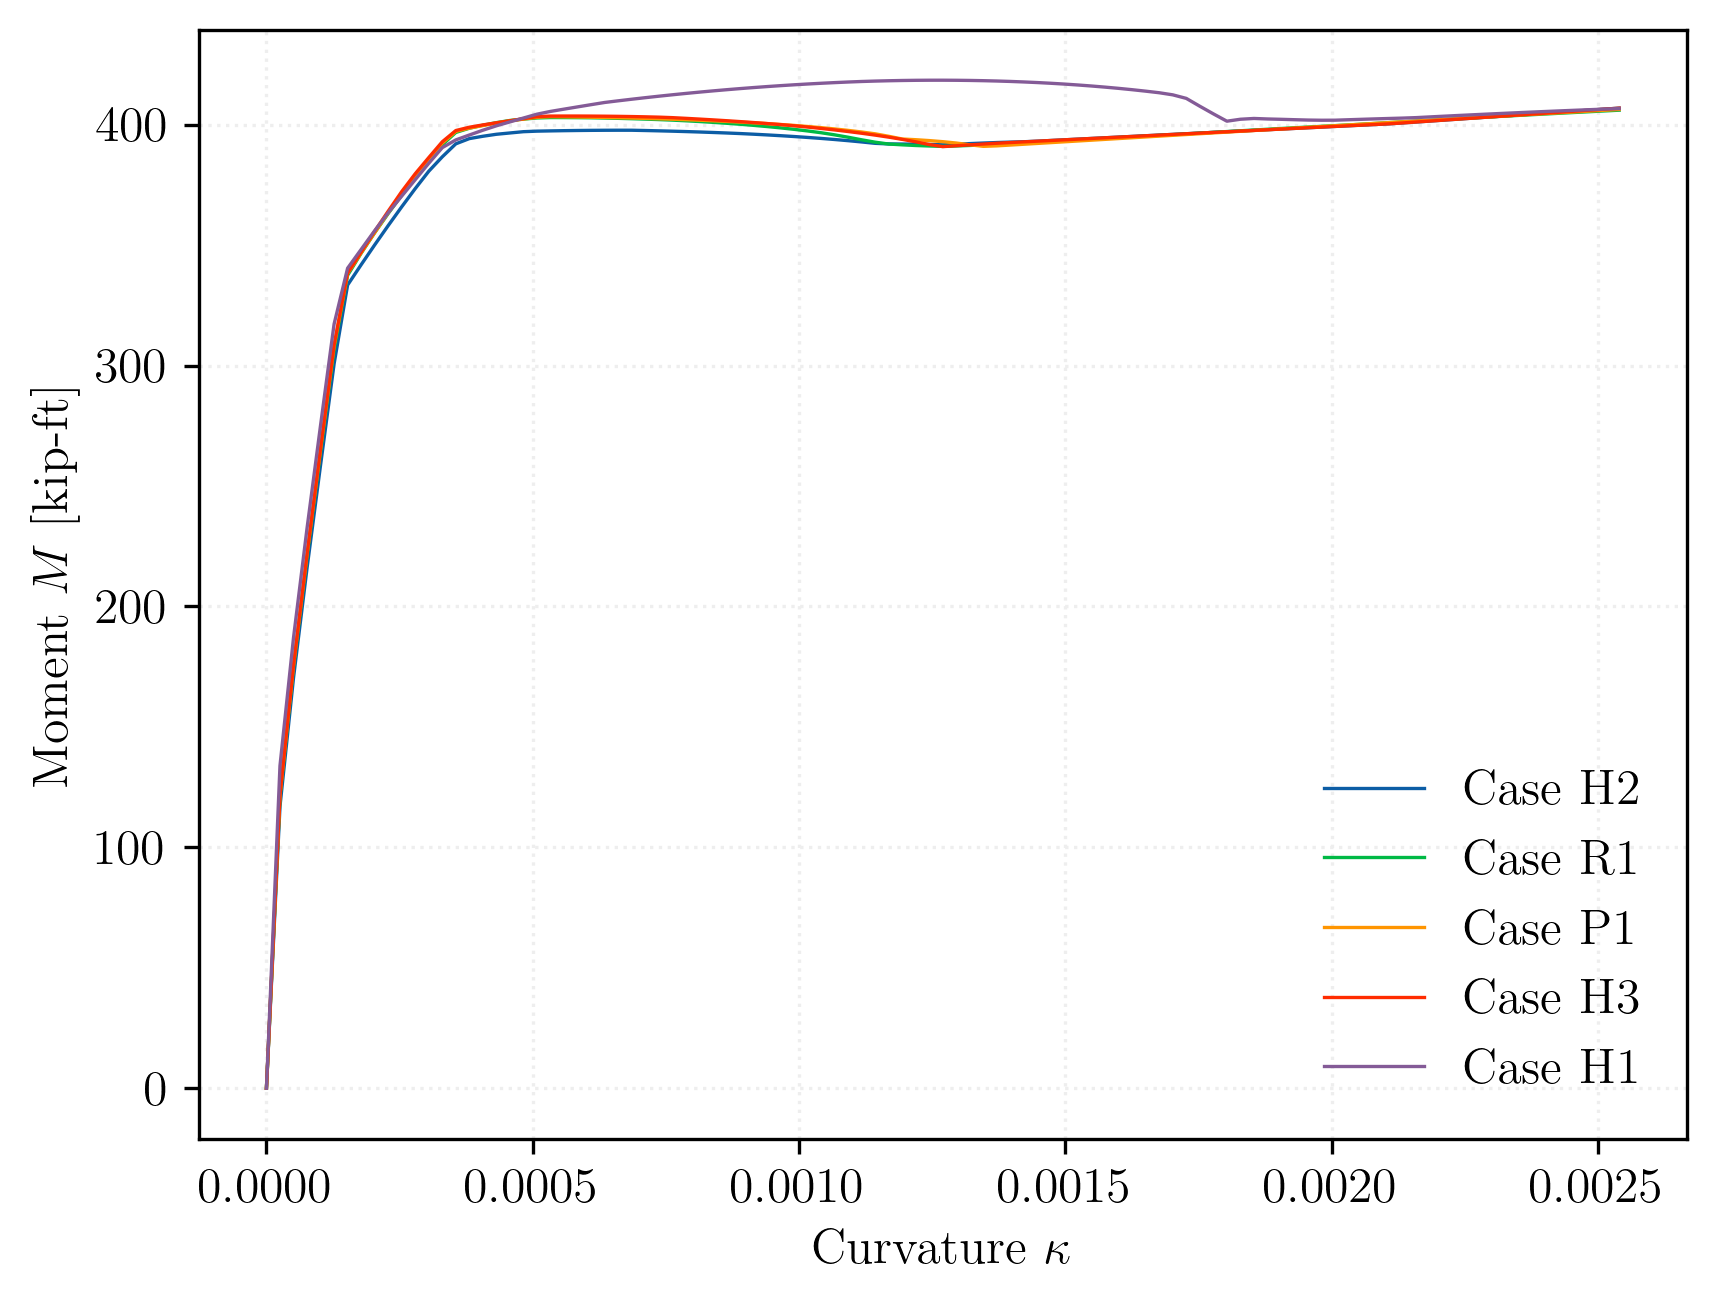

In [9]:
import matplotlib.pyplot as plt
for case in ["H2", "R1", "P1", "H3", "H1"]:
    print(case)
    try:
        K, M = moment_curvature(case, P, Ky*mu, numIncr, 
                                y=(0.0, 1.0, 0.0) if case in {"H1", "H2", "H3", "R1"} else (0.0, 0.0, 1.0)
                                , multiaxial=(case == "H1")
                                )
        plt.plot(K, M/(kip*foot), label=f"Case {case}") # 
    except Exception as e:
        raise e
        print(f"Error occurred while processing case {case}: {e}")
plt.grid(True)
plt.legend()
plt.xlabel("Curvature $\\kappa$")
plt.ylabel("Moment $M$ [kip-ft]");

H1  Area =  359.99999 (core =  250.196002 , cover =  104.993428 , rebar =  4.81056 )
H2  Area =  355.81056 (core =  252.0 , cover =  99.0 , rebar =  4.81056 )
H3  Area =  364.81056 (core =  252.0 , cover =  108.0 , rebar =  4.81056 )
R1  Area =  359.999994 (core =  250.196054 , cover =  104.99338 , rebar =  4.81056 )
P1  Area =  364.8 (core =  252.0 , cover =  108.0 , rebar =  4.8 )
Area =  364.8 (core =  0 , cover =  0 , rebar =  0 )


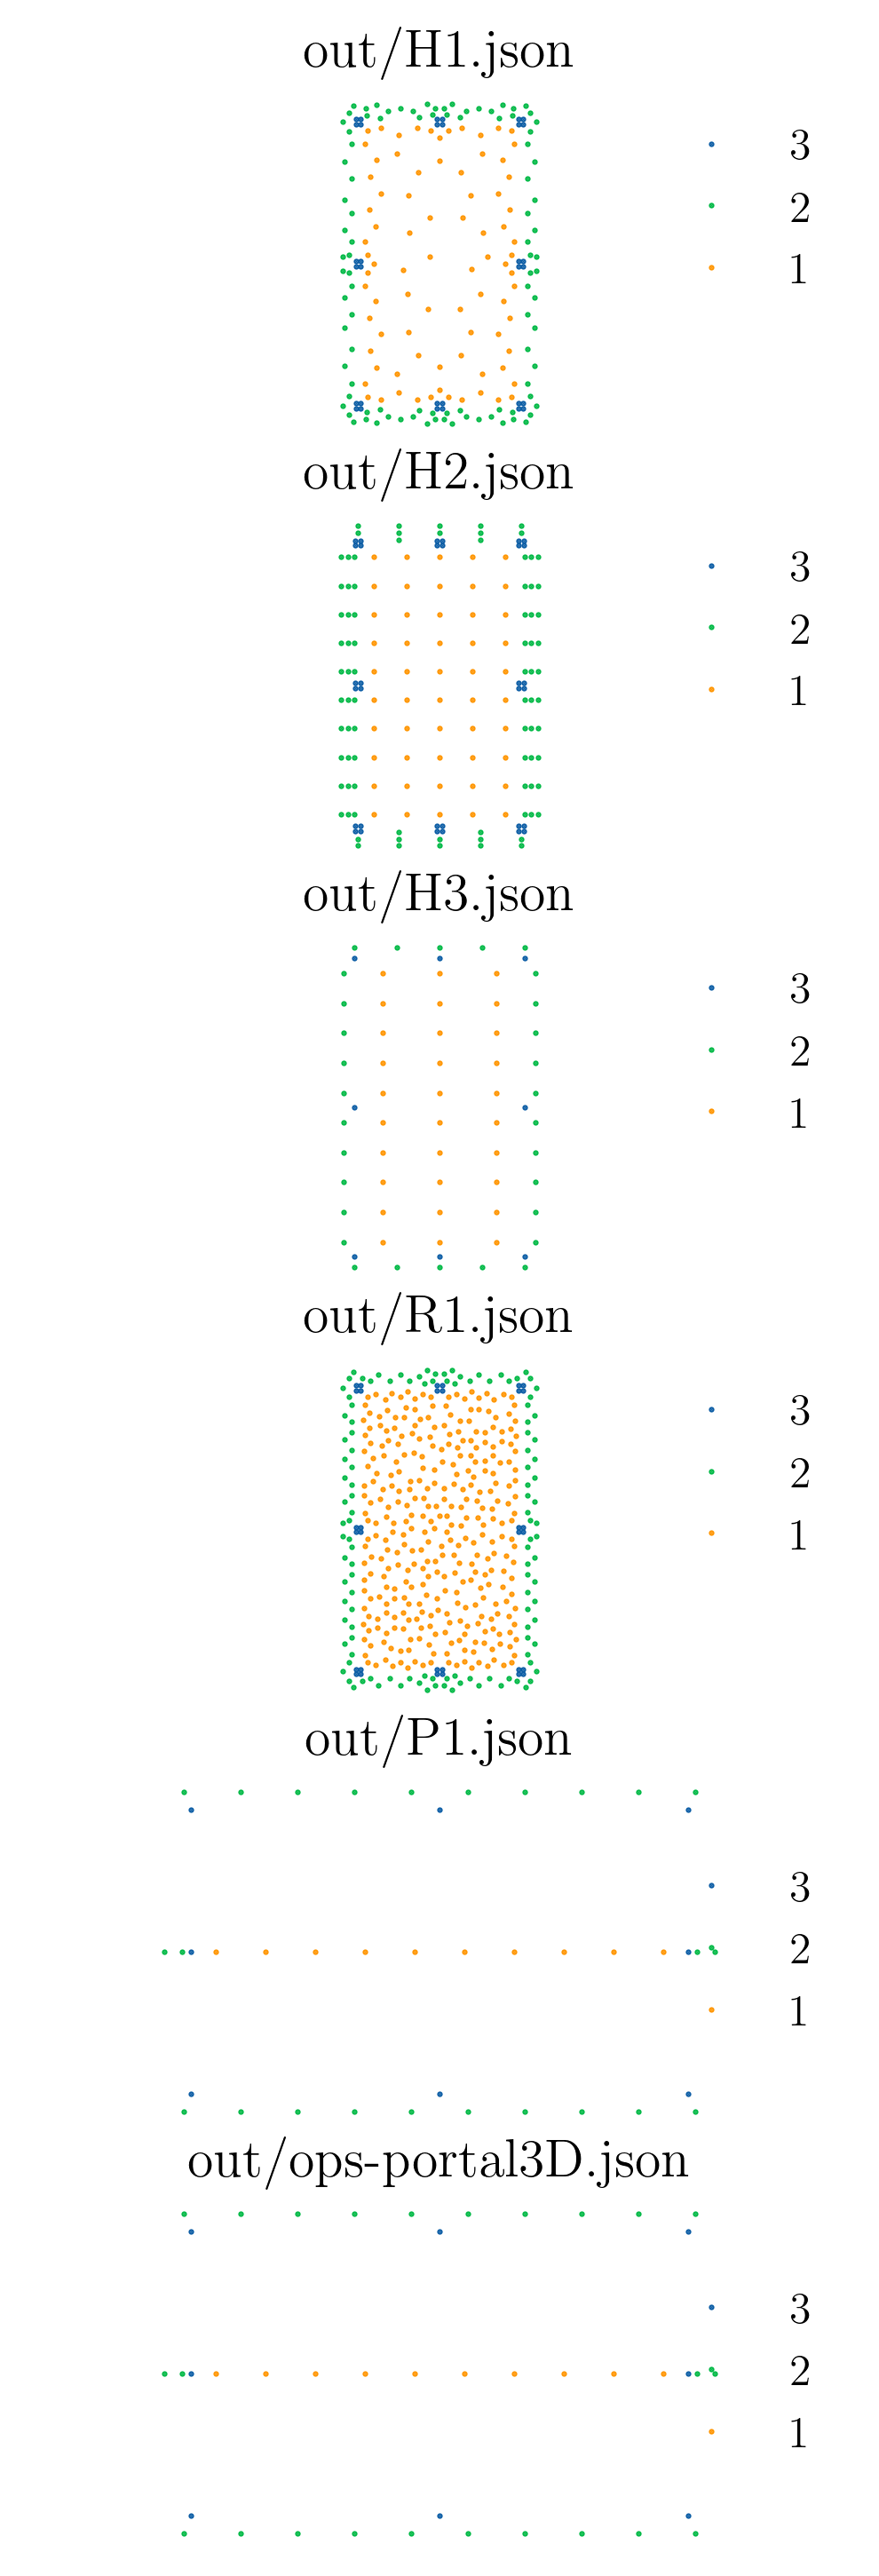

In [10]:

fig, ax = plt.subplots(6, figsize=(4, 12))
def plot_fibers(filename, ax):
    import json
    from collections import defaultdict
    with open(filename, "r") as f:
        data = json.load(f)
    fibers = data["StructuralAnalysisModel"]["properties"]["sections"][0]["fibers"]

    xy = defaultdict(list)
    print("Area = ", sum(fiber["area"] for fiber in fibers),
          "(core = ", sum(fiber["area"] for fiber in fibers if fiber["material"] == 1),
          ", cover = ", sum(fiber["area"] for fiber in fibers if fiber["material"] == 2),
          ", rebar = ", sum(fiber["area"] for fiber in fibers if fiber["material"] == 3), ")")
    for fiber in fibers:
        if "coord" in fiber:
            xy[int(fiber["material"])].append(fiber["coord"])
        else:
            xy[int(fiber["material"])].append(fiber["location"])
    for material in reversed(sorted(xy)):
        coords = np.array(xy[material])
        marker = "." if material < 3 else "."
        ax.plot(coords[:,0], coords[:,1], marker, label=material, markersize=1)

    ax.set_title(filename)
    ax.legend()
    ax.axis("equal")
    ax.axis("off")

for i, case in enumerate(["H1", "H2", "H3", "R1", "P1"]):
    print(case, end="  ")
    plot_fibers(f"out/{case}.json", ax[i])
# plot_fibers("a.json", ax[1])
plot_fibers("out/ops-portal3D.json", ax[5])